In [78]:
# 🔧 DIAGNÓSTICO DE ERRO CUDA - Execute antes de treinar
import torch
import torch.cuda as cuda

print("="*80)
print("📊 DIAGNÓSTICO DO SISTEMA GPU")
print("="*80)

# Verificar GPU
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"GPU encontrada: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Nenhuma'}")

if torch.cuda.is_available():
    # Limpar cache antes de começar
    print("\n🧹 Limpando cache de GPU...")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Informações de memória
    props = torch.cuda.get_device_properties(0)
    total_memory = props.total_memory / 1e9
    print(f"Memória total da GPU: {total_memory:.2f} GB")

    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"Memória alocada: {allocated:.2f} GB")
    print(f"Memória reservada: {reserved:.2f} GB")
    print(f"Memória livre: {(total_memory - reserved):.2f} GB")

    # Verificar compatibilidade
    print(f"\nVersão CUDA: {torch.version.cuda}")
    print(f"Versão cuDNN: {torch.backends.cudnn.version()}")
    print(f"cuDNN habilitado: {torch.backends.cudnn.enabled}")

else:
    print("⚠️  CUDA não disponível! Usando CPU (muito lento).")

print("="*80 + "\n")

📊 DIAGNÓSTICO DO SISTEMA GPU
CUDA disponível: True
GPU encontrada: NVIDIA GeForce RTX 4060

🧹 Limpando cache de GPU...
Memória total da GPU: 8.18 GB
Memória alocada: 0.11 GB
Memória reservada: 0.13 GB
Memória livre: 8.06 GB

Versão CUDA: 12.8
Versão cuDNN: 91002
cuDNN habilitado: True



In [79]:
import pandas as pd
from PIL import Image, ImageChops
import numpy as np
import torch
from sklearn.model_selection import KFold
from torch.utils.data import  DataLoader, TensorDataset, Dataset
from torch import nn
import timm
from tqdm.notebook import tqdm
import torch.optim as optim
import os
from lib.load_dataset.loadDataset import LoadDataset

In [80]:
## Load images to test

FILE_PATH = "../../dataset_AFIB_Others/data_balanced_AFIB_OTHERS.csv"
path = '/home/leo/Documents/dev/oca-ia/dataset_AFIB_Others/data/'

print(f"Leitura e carregamento otimizado do arquivo '{FILE_PATH}'...\n")
N_samples = 3000  # Limite de amostras para teste rápido
## concat file_path and file_path_aug and read both csvs and concatenate the dataframes

# 1️⃣ EXPLORAR CSV PRIMEIRO
data = LoadDataset.explore_csv(FILE_PATH, max_rows=10)


## CSV concat com data augumentation

print(f"\n📌 Após concatenação com data augmentation: {len(data)} amostras") 
1

Leitura e carregamento otimizado do arquivo '../../dataset_AFIB_Others/data_balanced_AFIB_OTHERS.csv'...

📋 EXPLORAÇÃO DO ARQUIVO CSV
✓ Arquivo encontrado: ../../dataset_AFIB_Others/data_balanced_AFIB_OTHERS.csv
  Tamanho do arquivo: 0.07 MB

📖 Lendo arquivo CSV...
✓ CSV lido com sucesso!
  Shape: (4514, 2) (linhas, colunas)
  Colunas: ['path', 'label']
  Tipos de dados:
path       str
label    int64
dtype: object

📊 Valores Nulos:
  ✓ Nenhum valor nulo encontrado!
📄 Primeiras 10 linhas:
             path  label
0  15857_lr-0.png      0
1  15824_lr-0.png      1
2  21151_lr-0.png      0
3  00703_lr-0.png      1
4  15201_lr-0.png      0
5  12649_lr-0.png      0
6  03548_lr-0.png      1
7  03358_lr-0.png      0
8  12522_lr-0.png      0
9  04591_lr-0.png      0

📈 Estatísticas básicas:
  Total de amostras: 4514
  Distribuição de labels (label):
label
0    3000
1    1514

📌 Após concatenação com data augmentation: 4514 amostras


1

In [81]:
data

,path,label
0,15857_lr-0.png,0
1,15824_lr-0.png,1
2,21151_lr-0.png,0
3,00703_lr-0.png,1
4,15201_lr-0.png,0
...,...,...
4509,10763_lr-0.png,1
4510,01981_lr-0.png,0
4511,05834_lr-0.png,0
4512,10625_lr-0.png,1


In [82]:

if data is None:
    print("❌ Não foi possível continuar. Verifique o arquivo CSV.")
else:
    # 2️⃣ RENOMEAR COLUNAS PARA PADRONIZAÇÃO
    print("\n🏷️  Padronizando nomes de colunas...")
    if data.shape[1] >= 2:
        data.rename(columns={data.columns[0]: 'path', data.columns[1]: 'label'}, inplace=True)
        print(f"✓ Colunas renomeadas: {list(data.columns[:2])}\n")

    # 3️⃣ CARREGAR IMAGENS COM VALIDAÇÃO
    img_dataset, data, error_count = LoadDataset.validate_and_load_images(
        data=data,
        image_path_prefix=path,  # path definido anteriormente
        n_samples=N_samples,
        max_errors=10
    )

    # 4️⃣ ESTATÍSTICAS DAS IMAGENS
    LoadDataset.get_image_statistics(img_dataset)

    # 5️⃣ RESUMO FINAL
    print("\n" + "="*80)
    print("✅ RESUMO FINAL DO CARREGAMENTO")
    print("="*80)
    print(f"Arquivo CSV: {FILE_PATH}")
    print(f"Total de amostras: {len(data)}")
    print(f"Shape de imagens: {img_dataset.shape}")
    print(f"Distribuição de labels:")
    print(data['label'].value_counts().to_string())
    print("="*80 + "\n")



🏷️  Padronizando nomes de colunas...
✓ Colunas renomeadas: ['path', 'label']


🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS

📌 Configuração:
  Amostras a processar: 3000
  Prefixo de caminho: /home/leo/Documents/dev/oca-ia/dataset_AFIB_Others/data/
  Máximo de erros permitidos: 10

💾 Memória disponível: 21.16 GB
  Memória estimada para imagens: 0.55 GB

🔄 Carregando imagens...


Carregando imagens: 100%|██████████| 3000/3000 [02:41<00:00, 18.61it/s]



✅ Carregamento concluído!
  Imagens carregadas com sucesso: 3000
  Imagens com erro: 0
  Shape final: (3000, 3, 256, 256)

📊 ESTATÍSTICAS DAS IMAGENS
Shape: (3000, 3, 256, 256)
Tipo de dado: uint8
Min: 0
Max: 255
Média: 233.51
Std: 28.96
Memória total: 562.50 MB

✅ RESUMO FINAL DO CARREGAMENTO
Arquivo CSV: ../../dataset_AFIB_Others/data_balanced_AFIB_OTHERS.csv
Total de amostras: 3000
Shape de imagens: (3000, 3, 256, 256)
Distribuição de labels:
label
0    2005
1     995



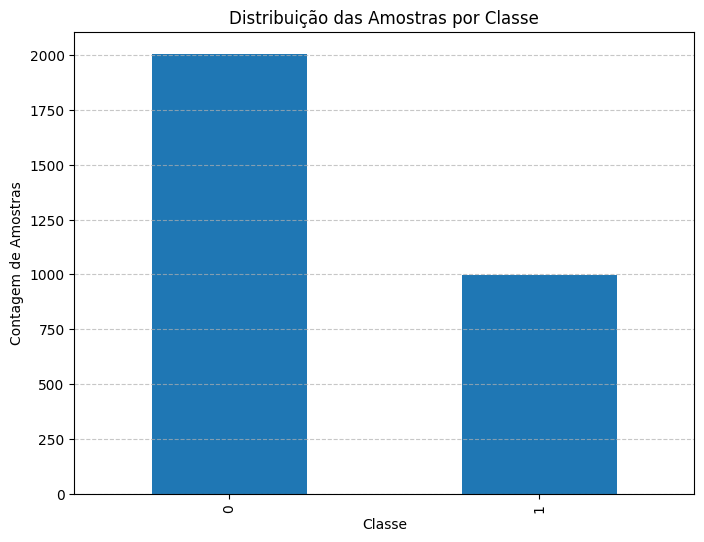

In [116]:
## Distribuicao das amostras
## Histograma da distribuicao das amostras
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
data['label'].value_counts().plot(kind='bar')
plt.title('Distribuição das Amostras por Classe')
plt.xlabel('Classe')
plt.ylabel('Contagem de Amostras')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [84]:
tensor_imagem = torch.from_numpy(img_dataset)

In [85]:
tensor_imagem

tensor([[[[254, 254, 254,  ..., 254, 254, 254],
          [255, 255, 255,  ..., 255, 255, 255],
          [254, 254, 254,  ..., 254, 254, 254],
          ...,
          [155, 169, 252,  ..., 254, 254, 254],
          [148, 163, 252,  ..., 255, 255, 255],
          [197, 205, 253,  ..., 254, 254, 254]],

         [[243, 241, 241,  ..., 238, 214, 244],
          [248, 247, 246,  ..., 243, 211, 250],
          [243, 241, 241,  ..., 239, 213, 244],
          ...,
          [152, 166, 248,  ..., 248, 221, 254],
          [142, 156, 242,  ..., 242, 210, 249],
          [185, 192, 239,  ..., 238, 214, 244]],

         [[241, 239, 239,  ..., 236, 212, 242],
          [247, 245, 244,  ..., 242, 211, 249],
          [241, 240, 239,  ..., 237, 212, 243],
          ...,
          [151, 164, 246,  ..., 246, 220, 252],
          [141, 155, 241,  ..., 240, 209, 248],
          [183, 190, 237,  ..., 236, 212, 242]]],


        [[[254, 254, 254,  ..., 254, 254, 254],
          [255, 255, 255,  ..., 255

In [86]:

print("Tensor de Rotulos sendo gerado...")


tensor_label = torch.tensor(np.array(data['label'].astype("uint8"))).unsqueeze(1)
print("Tensor de Rotulos gerado com sucesso. Tamanho do Tensor:", tensor_label.shape)


print("Iniciando o treinamento com K-Fold Cross Validation...")


test_dataset = TensorDataset(tensor_imagem, tensor_label)
test_loader_img = DataLoader(test_dataset, batch_size=1, shuffle=True)


Tensor de Rotulos sendo gerado...
Tensor de Rotulos gerado com sucesso. Tamanho do Tensor: torch.Size([3000, 1])
Iniciando o treinamento com K-Fold Cross Validation...


## Load Model

In [117]:
#from models import ECGClassifierResnet
from torch import nn
import timm
class ECGClassifierResnet(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierResnet, self).__init__()
        # Where we define all the parts of the model
        #self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.base_model=timm.create_model('resnet50d.ra4_e3600_r224_in1k',pretrained=True)
        #self.base_model = timm.create_model('vit_mediumd_patch16_reg4_gap_256.sbb2_e200_in12k_ft_in1k',num_classes=5,pretrained=True)

        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 2048        # Make a classifier
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
            #nn.Dropout(0.7),           # Dropout para regularização (reduz overfitting)
            nn.ReLU(),
           # nn.Dropout(0.5),           # Dropout adicional antes da saída
            nn.Linear(enet_out_size, 2)
        ) # saida como Softmax para classificacao single label

    def forward(self, x):
        # Connect these parts and return the output
        #converte 1 canal para 3 canais (RGB) usando uma camada Conv2d
        #x1 = nn.Conv2d(3, 1, kernel_size=3, stride=1, padding=1)(x)  # Converte de 1 canal para 3 canais
        x = self.features(x)
        output = self.classifier(x)
        #output = nn.Softmax(dim=1)(output)
        return output


In [118]:
## Load models 
model = ECGClassifierResnet()
model.to('cuda' if torch.cuda.is_available() else 'cpu')
weights = torch.load('/home/leo/Documents/dev/oca-ia/execute_terminal/4000-files-augument/output/model_fold_4.pth')
model.load_state_dict(weights)


<All keys matched successfully>

In [108]:
len(test_loader_img.dataset)

3000

In [119]:
pred_train = np.zeros(len(test_loader_img.dataset), dtype=np.uint8)
pred_train[1]=0

In [122]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
#model.to(device)
# pred_train as nu8mpy array
pred_train = np.zeros(len(test_loader_img.dataset), dtype=np.uint8)
i=0
with torch.no_grad():
    #model.eval()  # Coloca o modelo em modo de avaliação
    for image, label in test_loader_img:
        image_ref = image.to(device)
       # print(image_ref.float())
        #print(f"Shape da imagem de entrada: {image.shape}")
        output =model(image_ref.float())
        pred_train_cpu  = torch.argmax(output, dim=1)
        pred_train[i] = pred_train_cpu.item()  # Converte tensor para valor escalar e armazena no array
        i+=1
        #print(f"Predição do modelo: {pred_train[-1]}, Label real: {label}, output raw: {output}")


In [111]:
torch.cuda.empty_cache()

In [112]:
output = [[0.1  ,0.9], [0.8, 0.2], [0.4, 0.6]]
torch.argmax(torch.tensor(output), dim=1)

tensor([1, 0, 1])

In [113]:
labels.shape

(3000,)

output

In [114]:
pred_train.shape

(3000,)

In [123]:
## Calculo das métricas para pred_train e label
pred_train =pred_train

# Convertendo a lista de labels em um array numpy
labels = np.array(data['label'])
labels

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(labels, pred_train)
precision = precision_score(labels, pred_train, average='weighted')
recall = recall_score(labels, pred_train, average='weighted')
f1 = f1_score(labels, pred_train, average='weighted')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")    
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.343
Precision: 0.611880968622101
Recall: 0.343
F1 Score: 0.19808460629351068


In [97]:
data['label'].values

array([0, 1, 0, ..., 0, 0, 0], shape=(3000,))